In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("Bengaluru_House_Data.csv")

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [11]:
print(df.shape)
print(df.columns)
print(df.describe())

(13303, 8)
Index(['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath',
       'balcony', 'price'],
      dtype='object')
               bath       balcony         price
count  13246.000000  12710.000000  13303.000000
mean       2.692586      1.584343    112.584033
std        1.341506      0.817287    148.993820
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


In [10]:
df.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,57
balcony,593
price,0


In [8]:
df = df.drop("society", axis=1)

In [9]:
df = df.dropna(subset=["location", "size"])

In [12]:
df["bhk"] = df["size"].apply(lambda x: int(x.split()[0]))

In [14]:
sorted(df["bhk"].unique())

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(16),
 np.int64(18),
 np.int64(19),
 np.int64(27),
 np.int64(43)]

In [16]:

def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

df[~df["total_sqft"].apply(is_float)]["total_sqft"].head(20)

,total_sqft
30,2100 - 2850
56,3010 - 3410
81,2957 - 3450
122,3067 - 8156
137,1042 - 1105
165,1145 - 1340
188,1015 - 1540
224,1520 - 1740
410,34.46Sq. Meter
549,1195 - 1440


In [ ]:
def convert_sqft_to_num(x):
    tokens = x.split("-")

    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2

    try:
        return float(x)
    except:
        return None
df["total_sqft"] = df["total_sqft"].apply(convert_sqft_to_num)
print(df["total_sqft"].head())

In [20]:
print(df["total_sqft"].head())

0    1056.0
1    2600.0
2    1440.0
3    1521.0
4    1200.0
Name: total_sqft, dtype: float64


In [24]:
print(df["total_sqft"].isnull().sum())
df = df.dropna(subset=["total_sqft"])
print(df.shape)
print(df["total_sqft"].dtype)

0
(13257, 9)
float64


In [26]:
print(df["bath"].median())
df["bath"] = df["bath"].fillna(df["bath"].median())
df["balcony"] = df["balcony"].fillna(0)

2.0


In [29]:
#df.isnull().sum()
df["price_per_sqft"] = (df["price"] * 100000) / df["total_sqft"]
print(df[["price", "total_sqft", "price_per_sqft"]].head())

    price  total_sqft  price_per_sqft
0   39.07      1056.0     3699.810606
1  120.00      2600.0     4615.384615
2   62.00      1440.0     4305.555556
3   95.00      1521.0     6245.890861
4   51.00      1200.0     4250.000000


In [32]:
df["sqft_per_bhk"] = df["total_sqft"] / df["bhk"]
print(df[["total_sqft", "bhk", "sqft_per_bhk"]].head())

   total_sqft  bhk  sqft_per_bhk
0      1056.0    2         528.0
1      2600.0    4         650.0
2      1440.0    3         480.0
3      1521.0    3         507.0
4      1200.0    2         600.0


In [35]:
df[df["sqft_per_bhk"] < 300].head(10)
df = df[df["sqft_per_bhk"] >= 300]
print(df.shape)

(12513, 11)


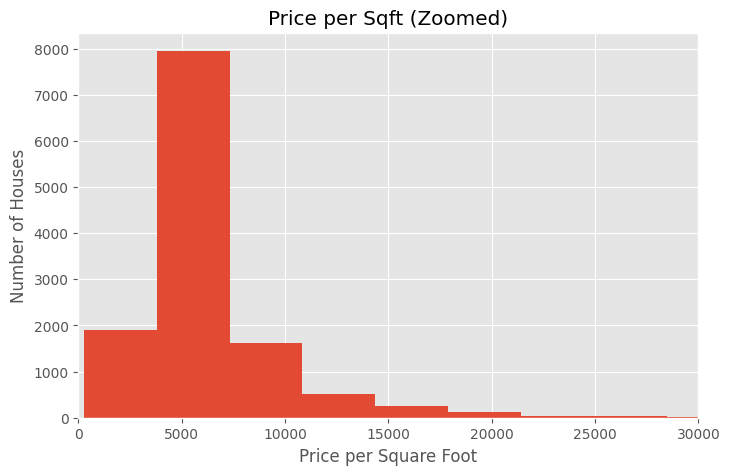

In [37]:
plt.figure(figsize=(8,5))
plt.hist(df["price_per_sqft"], bins=50)
plt.xlim(0, 30000)
plt.xlabel("Price per Square Foot")
plt.ylabel("Number of Houses")
plt.title("Price per Sqft")
plt.show()

In [39]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()

    for key, subdf in df.groupby("location"):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)

        reduced_df = subdf[
            (subdf.price_per_sqft >= (m - st)) &
            (subdf.price_per_sqft <= (m + st))
        ]

        df_out = pd.concat([df_out, reduced_df], ignore_index=True)

    return df_out
    df = remove_pps_outliers(df)

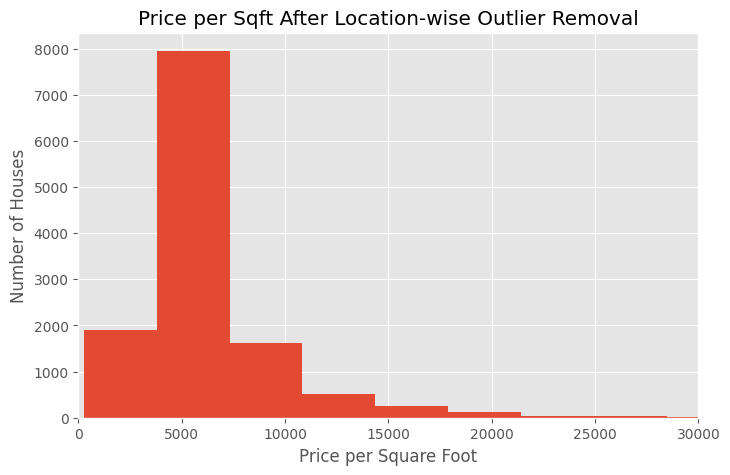

In [40]:
plt.figure(figsize=(8,5))
plt.hist(df["price_per_sqft"], bins=50)
plt.xlim(0, 30000)
plt.xlabel("Price per Square Foot")
plt.ylabel("Number of Houses")
plt.title("Price per Sqft After Location-wise Outlier Removal")
plt.show()

In [43]:
location_stats = df.groupby("location")["location"].count().sort_values(ascending=False)
#print(location_stats.head(20))
print(len(location_stats))
print(len(location_stats[location_stats <= 10]))

1215
993


In [48]:
location_less_than_10 = location_stats[location_stats <= 10]
#location_less_than_10.head()
df["location"] = df["location"].apply(
    lambda x: "other" if x in location_less_than_10 else x
)
print(df["location"].nunique())
df["location"].value_counts().head(15)

223


,count
location,
other,2728
Whitefield,536
Sarjapur Road,393
Electronic City,293
Kanakpura Road,269
Thanisandra,232
Yelahanka,207
Uttarahalli,180
Hebbal,176


In [52]:

df.columns
df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2


In [54]:
df = pd.get_dummies(
    df,
    columns=["area_type", "availability", "location"],
    drop_first=True
)


KeyError: "None of [Index(['area_type', 'availability', 'location'], dtype='object')] are in the [columns]"

In [56]:
print(df.head())
df.shape

   total_sqft  bath  balcony   price  bhk  area_type_Carpet  Area  \
0      1056.0   2.0      1.0   39.07    2                   False   
1      2600.0   5.0      3.0  120.00    4                   False   
2      1440.0   2.0      3.0   62.00    3                   False   
3      1521.0   3.0      1.0   95.00    3                   False   
4      1200.0   2.0      1.0   51.00    2                   False   

   area_type_Plot  Area  area_type_Super built-up  Area  availability_14-Nov  \
0                 False                            True                False   
1                  True                           False                False   
2                 False                           False                False   
3                 False                            True                False   
4                 False                            True                False   

   availability_15-Aug  ...  location_Vidyaranyapura  location_Vijayanagar  \
0                False  ..

(12513, 309)

In [58]:
X = df.drop("price", axis=1)
y = df["price"]
print(X.shape)
print(y.shape)

(12513, 308)
(12513,)


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [60]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10010, 308)
(2503, 308)
(10010,)
(2503,)


In [61]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [62]:
y_pred = lr.predict(X_test)
print(y_pred[:10])

[ 76.71217523  85.06508666  50.91315574 122.09598182 533.98578481
 105.42576044  88.67263779 368.08248219 112.882975    26.87985567]


In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 42.59449863604858
RMSE: 100.67287480954262
R² Score: 0.5114193289008879


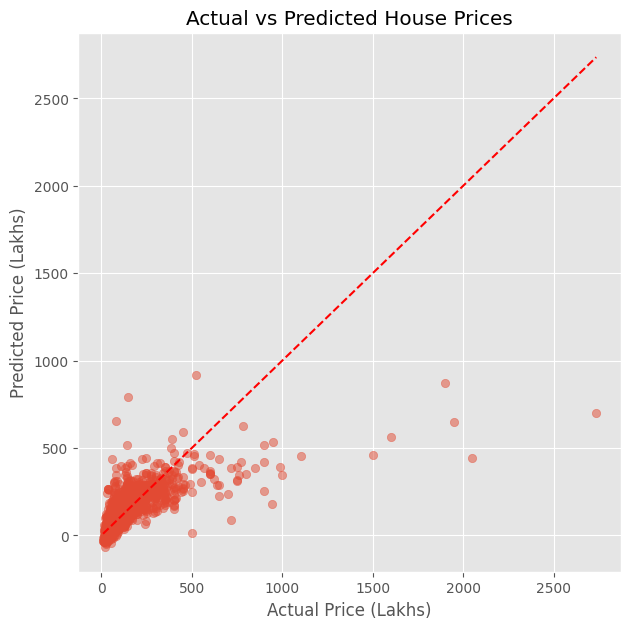

In [64]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [65]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [66]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R² :", dt_r2)

Decision Tree
MAE : 36.31705782469406
RMSE: 101.43540423253194
R² : 0.5039899578216942


In [67]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [68]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² :", rf_r2)

Random Forest
MAE : 31.130040633428838
RMSE: 90.97635529110225
R² : 0.6010041221406706


In [69]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [mae, dt_mae, rf_mae],
    "RMSE": [rmse, dt_rmse, rf_rmse],
    "R² Score": [r2, dt_r2, rf_r2]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,42.594499,100.672875,0.511419
1,Decision Tree,36.317058,101.435404,0.503990
2,Random Forest,31.130041,90.976355,0.601004


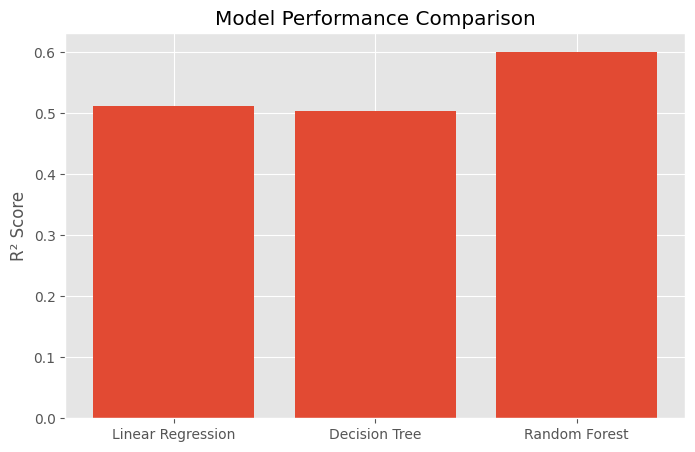

In [70]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R² Score"])
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.show()

In [71]:
import joblib

joblib.dump(rf, "house_price_model.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [72]:
def predict_price(area, bath, balcony, bhk, area_type, availability, location):
    sample = pd.DataFrame(0, index=[0], columns=X.columns)

    sample["total_sqft"] = area
    sample["bath"] = bath
    sample["balcony"] = balcony
    sample["bhk"] = bhk

    if f"area_type_{area_type}" in sample.columns:
        sample[f"area_type_{area_type}"] = 1

    if f"availability_{availability}" in sample.columns:
        sample[f"availability_{availability}"] = 1

    if f"location_{location}" in sample.columns:
        sample[f"location_{location}"] = 1
    elif "location_other" in sample.columns:
        sample["location_other"] = 1

    return rf.predict(sample)[0]

In [73]:
predict_price(
    area=1200,
    bath=2,
    balcony=1,
    bhk=2,
    area_type="Super built-up Area",
    availability="Ready To Move",
    location="Whitefield"
)

np.float64(55.15782857142858)